## 1) Carga de Datos


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("saber11_bogota_limpio_excel.csv", sep=";")

df.head()

,periodo,cole_area_ubicacion,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_naturaleza,cole_calendario,cole_jornada,cole_caracter,cole_bilingue,cole_genero,...,fami_tienecomputador,punt_global,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,desemp_ingles,estu_consecutivo,estrato_num
0,20194,urbano,bogota,bogota d.c.,oficial,a,tarde,academico,SIN REGISTRO,mixto,...,SI,278.0,58.0,57.0,59.0,46.0,62.0,a2,sb11201940399505,1.0
1,20152,urbano,bogota,bogota d.c.,no oficial,a,mañana,academico,n,mixto,...,NO,268.0,50.0,50.0,54.0,60.0,54.0,a1,sb11201520544825,2.0
2,20172,urbano,bogota,bogota d.c.,oficial,a,mañana,academico,SIN REGISTRO,mixto,...,NO,328.0,64.0,70.0,61.0,69.0,60.0,a2,sb11201720162770,2.0
3,20142,urbano,bogota,bogota d.c.,oficial,a,tarde,academico,n,mixto,...,SI,331.0,69.0,67.0,66.0,65.0,59.0,a2,sb11201420094691,3.0
4,20162,urbano,bogota,bogota d.c.,oficial,a,mañana,academico,n,mixto,...,SI,306.0,63.0,62.0,62.0,58.0,65.0,a2,sb11201620342593,1.0


In [18]:
df["punt_global"].describe()

count    536615.000000
mean        273.724961
std          48.677630
min           0.000000
25%         239.000000
50%         272.000000
75%         306.000000
max         494.000000
Name: punt_global, dtype: float64

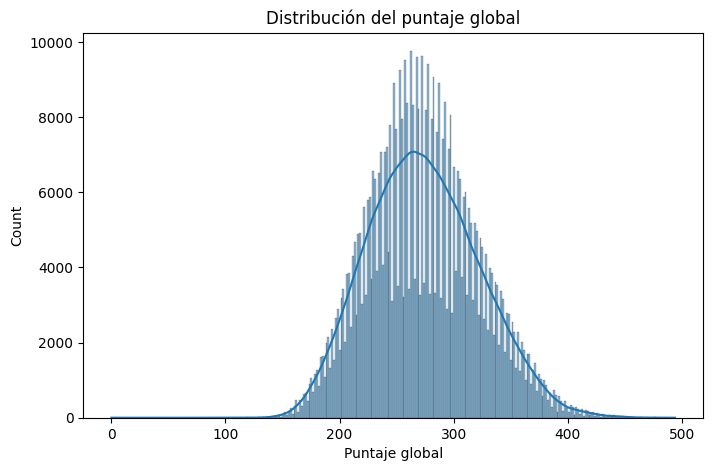

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["punt_global"], kde=True)
plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global")
plt.show()

In [20]:
df.groupby("cole_naturaleza")["punt_global"].agg(["count","mean","std","median"])

,count,mean,std,median
cole_naturaleza,,,,
no oficial,258944,288.234788,52.384128,289.0
oficial,277671,260.193722,40.506377,259.0


In [21]:
oficial = df[df["cole_naturaleza"]=="oficial"]["punt_global"]
no_oficial = df[df["cole_naturaleza"]=="no oficial"]["punt_global"]

stats.ttest_ind(oficial, no_oficial, equal_var=False)

TtestResult(statistic=np.float64(-218.2578004766688), pvalue=np.float64(0.0), df=np.float64(487016.5147060469))

In [22]:
df_bilingue = df[df["cole_bilingue"] != "SIN REGISTRO"]
df_bilingue.groupby("cole_bilingue")["punt_global"].agg(["count","mean","std","median"])

,count,mean,std,median
cole_bilingue,,,,
n,442305,272.916944,47.357012,271.0
s,15209,349.973700,40.105379,353.0


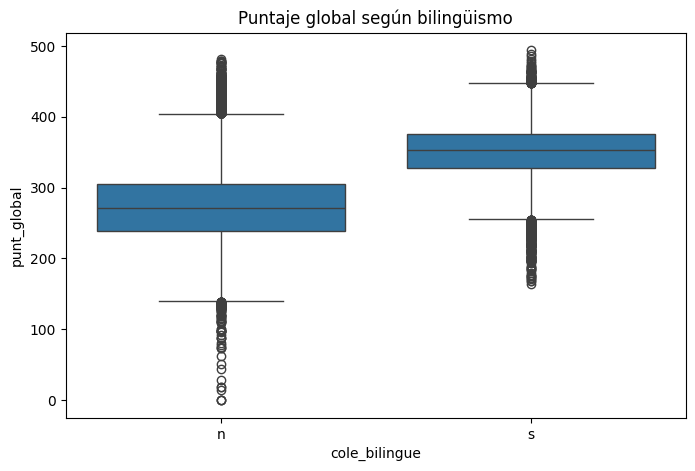

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cole_bilingue", y="punt_global", data=df_bilingue)
plt.title("Puntaje global según bilingüismo")
plt.show()

In [28]:
bilingue = df_bilingue[df_bilingue["cole_bilingue"]=="s"]["punt_global"]
no_bilingue = df_bilingue[df_bilingue["cole_bilingue"]=="n"]["punt_global"]

stats.ttest_ind(bilingue, no_bilingue, equal_var=False)

TtestResult(statistic=np.float64(231.46706451138593), pvalue=np.float64(0.0), df=np.float64(16699.93004150375))

In [30]:
df_bilingue.groupby(["cole_naturaleza","cole_bilingue"])["punt_global"].mean()

cole_naturaleza  cole_bilingue
no oficial       n                287.085438
                 s                349.973700
oficial          n                260.214460
Name: punt_global, dtype: float64

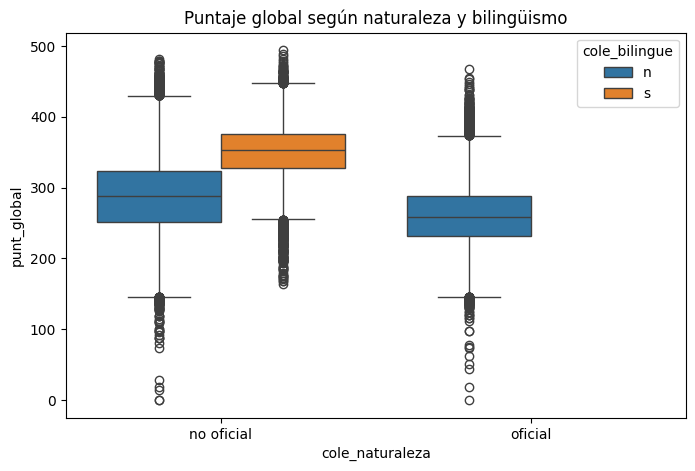

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cole_naturaleza", y="punt_global", hue="cole_bilingue", data=df_bilingue)
plt.title("Puntaje global según naturaleza y bilingüismo")
plt.show()